# Breast Cancer Gene Expression Classification Using Machine Learning

## Project Overview

This project analyzes breast cancer gene expression data using dimensionality reduction and machine learning techniques.

### Objectives

* Explore transcriptomic variation across breast cancer subtypes
* Visualize high-dimensional gene expression data using PCA
* Train machine learning models to classify cancer subtypes
* Evaluate predictive performance using classification metrics

### Dataset

* Breast cancer gene expression microarray dataset
* Source: CuMiDa / Kaggle
* ~54,000 gene expression features




In [1]:
# Import Libraries


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [2]:
# Download Dataset from KaggleHub

!pip install kagglehub

import kagglehub

# Download latest version of dataset
path = kagglehub.dataset_download(
    "brunogrisci/breast-cancer-gene-expression-cumida"
)

print("Path to dataset files:", path)

# Display dataset files
print(os.listdir(path))


Path to dataset files: /Users/lisaricanek/.cache/kagglehub/datasets/brunogrisci/breast-cancer-gene-expression-cumida/versions/2
['Breast_GSE45827.csv']


In [3]:
# Load Gene Expression Dataset


df = pd.read_csv(
    os.path.join(path, "Breast_GSE45827.csv")
)

# Preview dataset
print(df.head())

# Display dataset dimensions
print(df.shape)

# Display dataset information
print(df.info())

# Display column names
print(df.columns)

   samples   type  1007_s_at   1053_at    117_at    121_at  1255_g_at  \
0       84  basal   9.850040  8.097927  6.424728  7.353027   3.029122   
1       85  basal   9.861357  8.212222  7.062593  7.685578   3.149468   
2       87  basal  10.103478  8.936137  5.735970  7.687822   3.125931   
3       90  basal   9.756875  7.357148  6.479183  6.986624   3.181638   
4       91  basal   9.408330  7.746404  6.693980  7.333426   3.169923   

    1294_at   1316_at   1320_at  ...  AFFX-r2-Ec-bioD-3_at  \
0  6.880079  4.963740  4.408328  ...             12.229711   
1  7.542283  5.129607  4.584418  ...             12.178531   
2  6.562369  4.813449  4.425195  ...             12.125108   
3  7.802344  5.490982  4.567956  ...             12.111235   
4  7.610457  5.372469  4.424426  ...             12.173642   

   AFFX-r2-Ec-bioD-5_at  AFFX-r2-P1-cre-3_at  AFFX-r2-P1-cre-5_at  \
0             11.852955            13.658701            13.477698   
1             11.809408            13.750086      

In [4]:

# Explore Target Labels

print(df["type"].value_counts())


type
basal        41
HER          30
luminal_B    30
luminal_A    29
cell_line    14
normal        7
Name: count, dtype: int64


### Interpretation

The dataset contains multiple breast cancer subtypes, which will be used as target labels for multiclass classification.


In [5]:
# Data Preprocessing



# Remove non-feature columns
X = df.drop(columns=["samples", "type"])

# Target labels
y = df["type"]

In [6]:

# Encode Cancer Subtypes


encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)


In [7]:

# Standardize Gene Expression Features


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [8]:
# Perform PCA Dimensionality Reduction


pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)


(151, 2)


In [9]:
# Explained Variance


print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)


Explained variance ratio: [0.1118076  0.10185951]


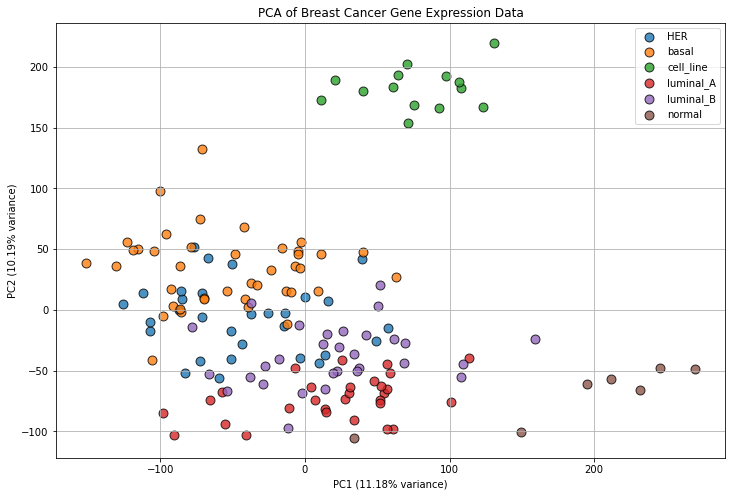

In [11]:
# PCA Visualization


plt.figure(figsize=(12, 8))

for label in np.unique(y_encoded):

    plt.scatter(
        X_pca[y_encoded == label, 0],
        X_pca[y_encoded == label, 1],
        s=80,
        alpha=0.8,
        edgecolors='black',
        label=encoder.inverse_transform([label])[0]
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)"
)

plt.title("PCA of Breast Cancer Gene Expression Data")

plt.legend()

plt.grid(True)


# Save PCA figure
plt.savefig(
    "pca_plot.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


### PCA Interpretation

The PCA plot demonstrates partial separation between breast cancer subtypes based on transcriptomic profiles.

Distinct clustering patterns suggest that several subtypes exhibit unique gene expression signatures, while overlap between groups reflects biological heterogeneity commonly observed in breast cancer.


In [12]:
# Machine Learning Classification


# Train/Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


In [13]:
# Train Logistic Regression Model


model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)


LogisticRegression(max_iter=5000)

In [14]:
# Generate Predictions


predictions = model.predict(X_test)


In [15]:
# Calculate Accuracy

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9032258064516129


In [16]:
# Classification Report


print(
    classification_report(
        y_test,
        predictions
    )
)


              precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       1.00      0.88      0.93         8
           2       1.00      1.00      1.00         3
           3       0.83      0.83      0.83         6
           4       0.86      1.00      0.92         6
           5       1.00      0.50      0.67         2

    accuracy                           0.90        31
   macro avg       0.92      0.87      0.88        31
weighted avg       0.91      0.90      0.90        31



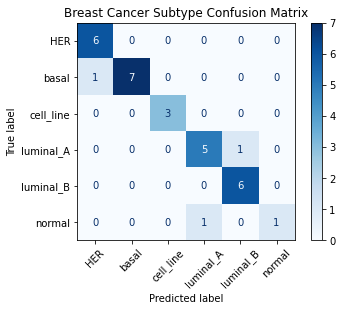

In [17]:
# Confusion Matrix


cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap='Blues')

plt.title("Breast Cancer Subtype Confusion Matrix")

plt.xticks(rotation=45)



# Save confusion matrix figure
plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Conclusion

This project demonstrates that machine learning models can classify breast cancer subtypes using high-dimensional gene expression data.

PCA analysis revealed biologically meaningful clustering patterns among several subtypes, while Logistic Regression achieved strong predictive performance on transcriptomic features.

## Future Improvements

* Random Forest classification
* Feature importance analysis
* t-SNE visualization
* Pathway enrichment analysis
* Deep learning approaches